<a href="https://colab.research.google.com/github/2422161csedscec-blip/Project-1/blob/main/Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Employee Attrition Prediction*

Objective

This project aims to predict employee attrition using a Logistic Regression classification model.
It uses the **IBM HR Analytics Employee Attrition & Performance** dataset to identify employees who are likely to leave the company.
The project includes data preprocessing, handling class imbalance with SMOTE, and evaluating the model using Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC-AUC.
The results help organizations improve employee retention through data-driven decisions.

In [37]:
import pandas as pd
import zipfile
import os

zip_file_path = "/content/archive (1).zip"
extracted_csv_name = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
extract_dir = "/content/"

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Construct the path to the extracted CSV file
csv_path = os.path.join(extract_dir, extracted_csv_name)

df = pd.read_csv(csv_path)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [38]:
# Dataset Shape
df.shape

# Dataset Information
df.info()

df.describe()

# Missing Values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


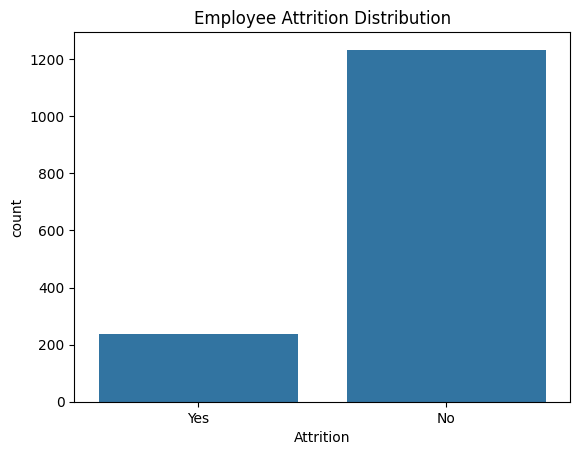

In [39]:
# Target Variable Distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Attrition', data=df)
plt.title("Employee Attrition Distribution")
plt.show()

In [40]:
# Data Preprocessing
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

df.head()



,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


In [41]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

X=df.drop("Attrition",axis=1)
y=df["Attrition"]

scaler=StandardScaler()

X=scaler.fit_transform(X)
X_scaled = pd.DataFrame(X, columns=df.drop("Attrition", axis=1).columns)

X_scaled.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0.446350,0.590048,0.742527,1.401512,-1.010909,-0.891688,-0.937414,0.0,-1.701283,-0.660531,...,-1.584178,0.0,-0.932014,-0.421642,-2.171982,-2.493820,-0.164613,-0.063296,-0.679146,0.245834
1,1.322365,-0.913194,-1.297775,-0.493817,-0.147150,-1.868426,-0.937414,0.0,-1.699621,0.254625,...,1.191438,0.0,0.241988,-0.164511,0.155707,0.338096,0.488508,0.764998,-0.368715,0.806541
2,0.008343,0.590048,1.414363,-0.493817,-0.887515,-0.891688,1.316673,0.0,-1.696298,1.169781,...,-0.658973,0.0,-0.932014,-0.550208,0.155707,0.338096,-1.144294,-1.167687,-0.679146,-1.155935
3,-0.429664,-0.913194,1.461466,-0.493817,-0.764121,1.061787,-0.937414,0.0,-1.694636,1.169781,...,0.266233,0.0,-0.932014,-0.421642,0.155707,0.338096,0.161947,0.764998,0.252146,-1.155935
4,-1.086676,0.590048,-0.524295,-0.493817,-0.887515,-1.868426,0.565311,0.0,-1.691313,-1.575686,...,1.191438,0.0,0.241988,-0.678774,0.155707,0.338096,-0.817734,-0.615492,-0.058285,-0.595227


In [42]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
X_train
X_test

array([[-1.41518107, -2.41643713,  0.06821073, ..., -1.16768726,
        -0.67914568, -1.15593471],
       [ 0.77485596,  0.59004834,  0.77971307, ...,  0.21280194,
         1.49386709,  0.80654148],
       [-0.64866811,  0.59004834, -0.28382179, ..., -0.0632959 ,
        -0.67914568, -0.87558097],
       ...,
       [-0.10115885,  0.59004834,  1.62012872, ..., -0.61549158,
        -0.05828489, -0.59522723],
       [ 2.08887817,  0.59004834,  1.12182918, ..., -0.61549158,
        -0.36871529, -1.15593471],
       [ 0.008343  ,  0.59004834,  1.41188414, ...,  2.14548682,
         0.8730063 ,  0.80654148]])

In [43]:
# Class Imbalance Handling
y.value_counts()

,count
Attrition,
0,1233
1,237


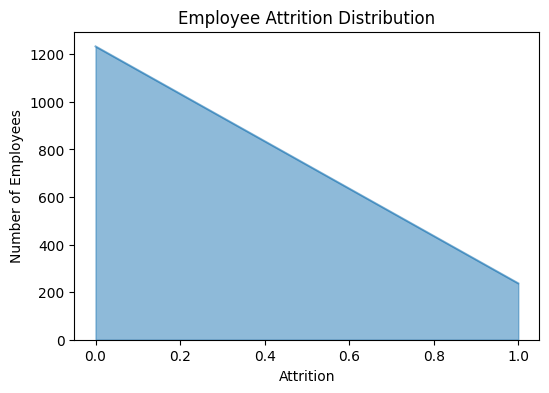

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

counts = y.value_counts().sort_index()

counts.plot(kind='area', figsize=(6,4), alpha=0.5)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

In [45]:
# apply SMOTE
from imblearn.over_sampling import SMOTE

smote=SMOTE(random_state=42)

X_train_smote,y_train_smote=smote.fit_resample(X_train,y_train)
print(X_train_smote.shape)
pd.Series(y_train_smote).value_counts()

(1972, 34)


,count
Attrition,
0,986
1,986


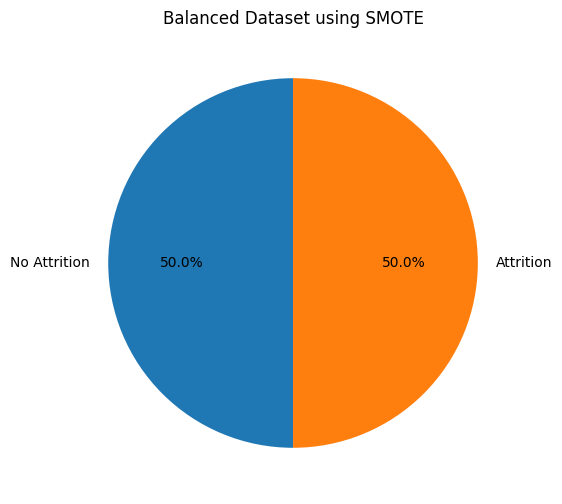

In [46]:

import matplotlib.pyplot as plt

counts = pd.Series(y_train_smote).value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=['No Attrition', 'Attrition'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Balanced Dataset using SMOTE")
plt.show()

In [47]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000)

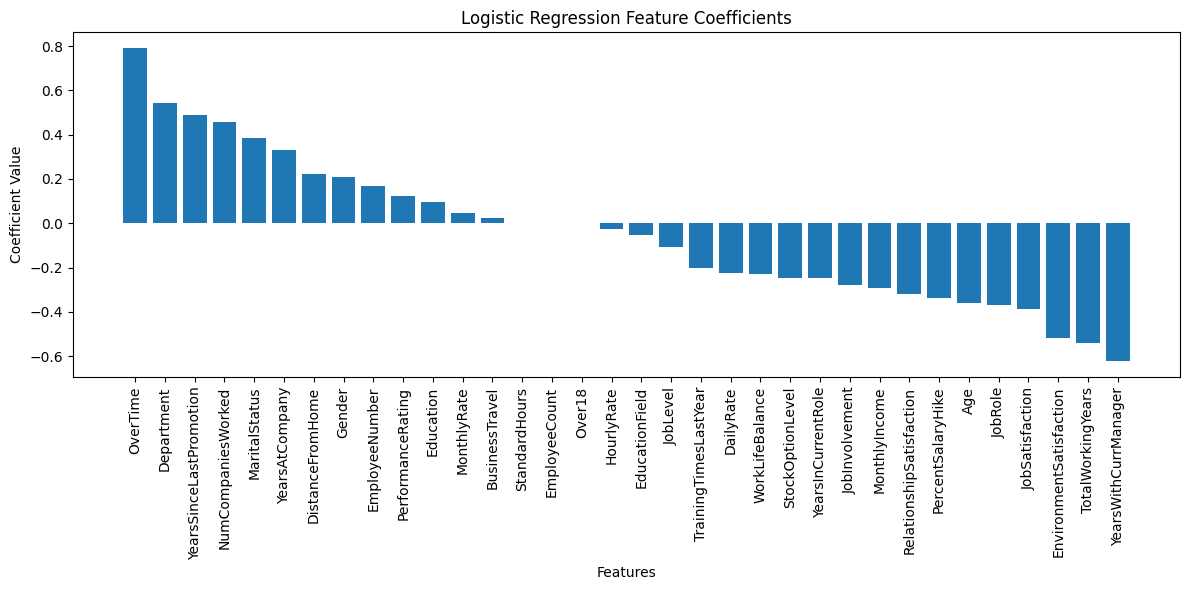

In [48]:
# Graph for Logistic Regression
import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame of coefficients
coefficients = pd.DataFrame({
    'Feature': df.drop('Attrition', axis=1).columns,
    'Coefficient': model.coef_[0]
})

# Sort coefficients
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

# Plot
plt.figure(figsize=(12,6))
plt.bar(coefficients['Feature'], coefficients['Coefficient'])

plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("Logistic Regression Feature Coefficients")

plt.tight_layout()
plt.show()

In [49]:
# Prediction
y_pred=model.predict(X_test)

y_prob=model.predict_proba(X_test)[:,1]
print("Predicted Class Labels:")
print(y_pred)

print("\nPredicted Probabilities:")
print(y_prob)

Predicted Class Labels:
[0 0 0 0 1 1 0 0 0 1 0 0 1 1 0 1 0 0 1 0 1 1 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0
 0 0 1 0 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0
 0 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 1 1 0 1 1 0 1 0 0 1 0 0 0 1 0 1
 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 1 1 0 1 0 1 1 0 0 1 1 0 0 0 0 0 1 1 0 1 0
 0 0 0 0 1 0 0 1 1 0 1 1 0 0 1 0 1 0 0 1 1 0 1 0 0 1 0 0 1 0 1 1 1 0 0 1 0
 0 0 0 0 1 1 0 1 0 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 1
 1 1 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 1 1 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 1 0 1 0 1 0 1 0 0 0 1 0 0]

Predicted Probabilities:
[0.45405327 0.0372622  0.48660416 0.00969302 0.79119476 0.65779213
 0.0654825  0.04932535 0.0327275  0.66835995 0.41145159 0.44643252
 0.53306675 0.61667098 0.36090525 0.85315878 0.08809328 0.08720565
 0.66543887 0.20153838 0.68429075 0.53616879 0.50519446 0.35315646
 0.05571011 0.88333727 0.27831366 0.12333505 0.04278961 0.04437757
 0.09121062 0.4019

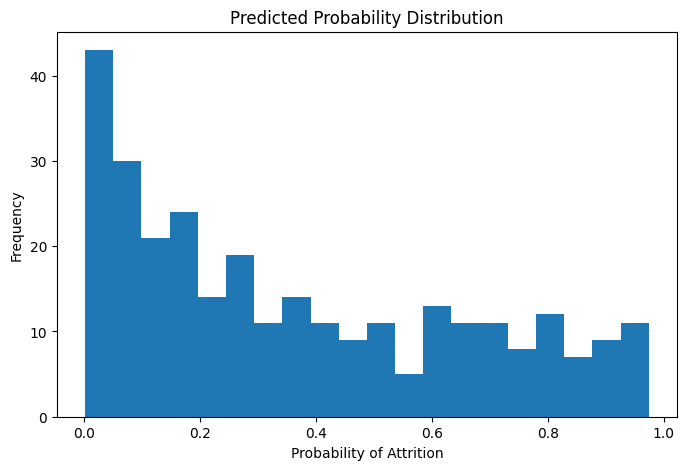

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(y_prob, bins=20)

plt.title("Predicted Probability Distribution")
plt.xlabel("Probability of Attrition")
plt.ylabel("Frequency")

plt.show()

In [51]:
# Accuracy
from sklearn.metrics import accuracy_score

accuracy=accuracy_score(y_test,y_pred)

print("Accuracy :",accuracy)

Accuracy : 0.7585034013605442


In [52]:
# Precision, Recall and F1 Score
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.76      0.84       247
           1       0.38      0.77      0.50        47

    accuracy                           0.76       294
   macro avg       0.66      0.76      0.67       294
weighted avg       0.85      0.76      0.79       294



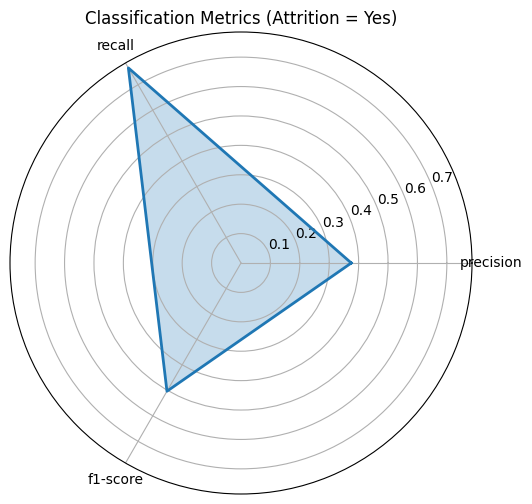

In [53]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

report = classification_report(y_test, y_pred, output_dict=True)

metrics = ['precision', 'recall', 'f1-score']
values = report['1']['precision'], report['1']['recall'], report['1']['f1-score']

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
values = np.concatenate((values, [values[0]]))
angles = np.concatenate((angles, [angles[0]]))

plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)

ax.plot(angles, values, linewidth=2)
ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)

plt.title("Classification Metrics (Attrition = Yes)")
plt.show()

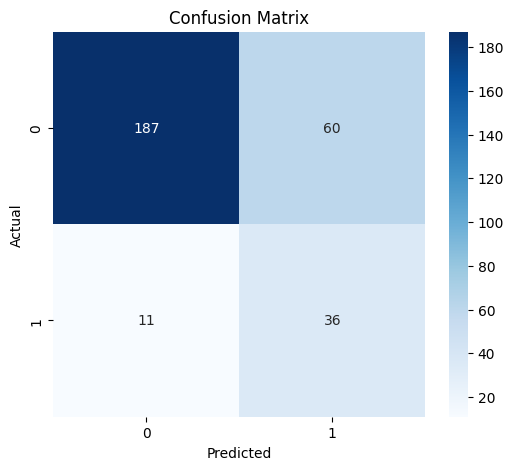

In [54]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

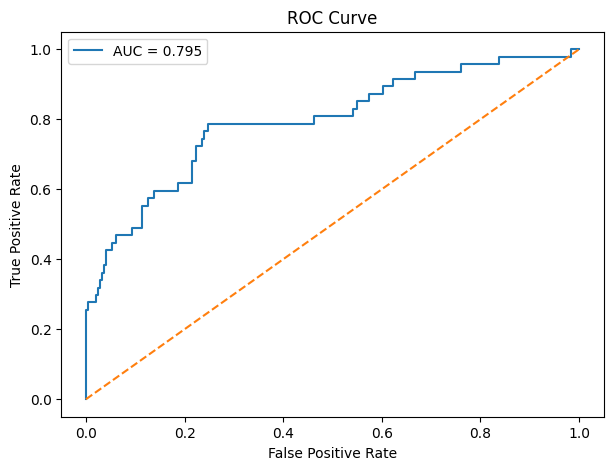

ROC-AUC Score : 0.794900508226376


In [55]:
# ROC Curve
from sklearn.metrics import roc_curve,roc_auc_score

fpr,tpr,threshold=roc_curve(y_test,y_prob)

auc=roc_auc_score(y_test,y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr,tpr,label="AUC = %.3f"%auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("ROC-AUC Score :",auc)

In [56]:
# feature Importance
importance=pd.DataFrame({
    "Feature":df.drop("Attrition",axis=1).columns,
    "Coefficient":model.coef_[0]
})

importance=importance.sort_values(by="Coefficient",ascending=False)

importance.head(10)

,Feature,Coefficient
21,OverTime,0.791413
3,Department,0.542114
32,YearsSinceLastPromotion,0.491024
19,NumCompaniesWorked,0.459255
16,MaritalStatus,0.382712
30,YearsAtCompany,0.329124
4,DistanceFromHome,0.221640
10,Gender,0.209305
8,EmployeeNumber,0.167844
23,PerformanceRating,0.123030


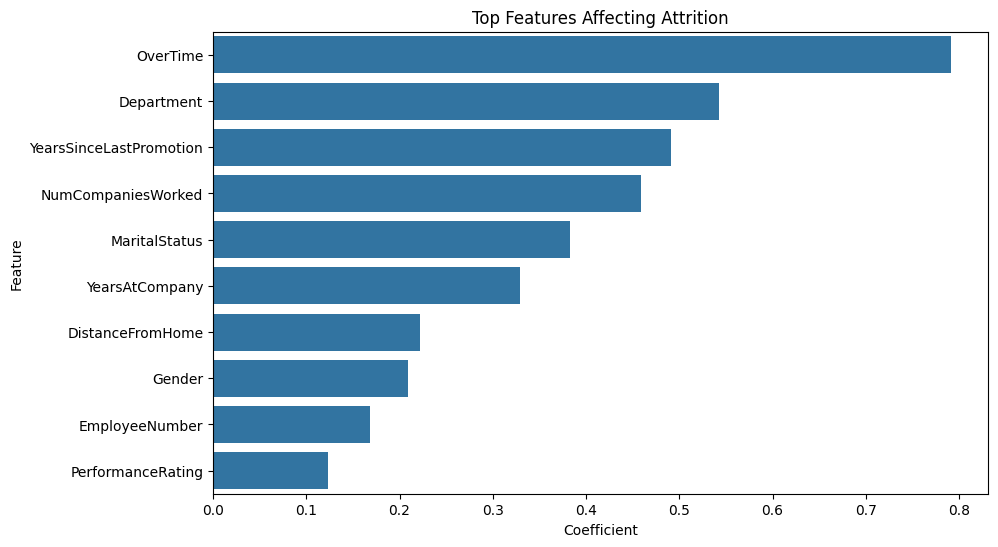

In [57]:
plt.figure(figsize=(10,6))

sns.barplot(data=importance.head(10),
            x="Coefficient",
            y="Feature")

plt.title("Top Features Affecting Attrition")

plt.show()

In [58]:
# Evaluation Metrics
from sklearn.metrics import precision_score,recall_score,f1_score

print("Precision :",precision_score(y_test,y_pred))

print("Recall :",recall_score(y_test,y_pred))

print("F1 Score :",f1_score(y_test,y_pred))

Precision : 0.375
Recall : 0.7659574468085106
F1 Score : 0.5034965034965035


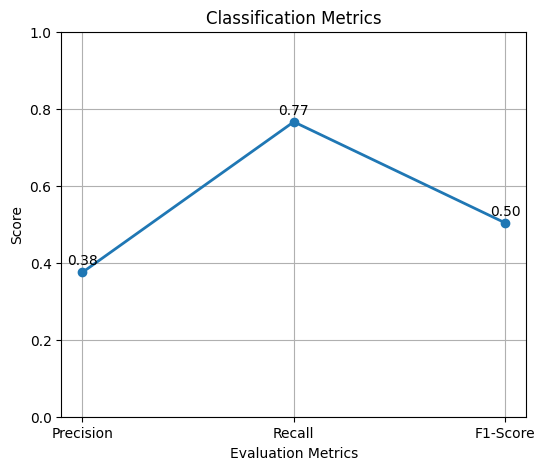

In [64]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics = ['Precision', 'Recall', 'F1-Score']
scores = [precision, recall, f1]

plt.figure(figsize=(6,5))
plt.plot(metrics, scores, marker='o', linewidth=2)

plt.title("Classification Metrics")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True)

for i, score in enumerate(scores):
    plt.text(i, score + 0.02, f'{score:.2f}', ha='center')

plt.show()

Conclusion

This project successfully developed a Logistic Regression model to predict employee attrition using the IBM HR Analytics Employee Attrition & Performance dataset. A systematic machine learning workflow was followed, including data preprocessing, feature encoding, feature scaling, and handling class imbalance using SMOTE to improve the model's reliability. The model's performance was evaluated using key classification metrics such as Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC-AUC, providing a comprehensive assessment of its predictive capability. The analysis also identified factors that influence employee attrition, offering valuable insights for Human Resource (HR) management. Overall, this project demonstrates how machine learning can support organizations in making data-driven decisions, improving employee retention strategies, and reducing workforce turnover.